# Lecture 17: Attention is Inner Products — a Transformer's Core in NumPy

### The operation that turns embeddings into a language model

`METHODOLOGY.md` claims that **attention** — the mechanism at the heart of every
model like Claude — is just *a matrix of inner products, softmaxed, used to take
a weighted sum*. That is Lecture 4 (inner products) and Lecture 8 (matrices)
combined. This lecture proves it by building one **self-attention head from
scratch in NumPy**, on real word vectors.

No deep-learning framework — only the linear algebra this course already
taught.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
np.set_printoptions(precision=3, suppress=True)
emb = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## Tokens become a matrix of vectors

A sentence is a sequence of tokens; each token is an embedding **vector**
(Lecture 3). Stack them and you get a matrix $X$ of shape (sequence length ×
dimension). We use individual words as 'tokens' and embed each one.

In [2]:
tokens = ['the', 'cat', 'sat', 'on', 'the', 'mat']
X = emb.encode(tokens, normalize_embeddings=True)   # (seq_len, d)
d = X.shape[1]
print('sequence matrix X:', X.shape, ' (one row per token)')

sequence matrix X: (6, 384)  (one row per token)


## Queries, keys, values — three projections of the same tokens

Attention asks, for each token: *which other tokens should I pay attention to?*
To do that it makes three linear projections of $X$ (Lecture 8 — matrix
multiplication):

- **Query** $Q = X W_Q$ — 'what am I looking for?'
- **Key** $K = X W_K$ — 'what do I offer?'
- **Value** $V = X W_V$ — 'what I'll contribute if attended to.'

In a trained model $W_Q, W_K, W_V$ are learned. Here we use fixed random
projections just to show the mechanism — the *operations* are the point.

In [3]:
rng = np.random.default_rng(0)
dk = 32                       # projected dimension
WQ = rng.normal(scale=0.1, size=(d, dk))
WK = rng.normal(scale=0.1, size=(d, dk))
WV = rng.normal(scale=0.1, size=(d, dk))

Q = X @ WQ
K = X @ WK
V = X @ WV
print('Q, K, V shapes:', Q.shape, K.shape, V.shape)

Q, K, V shapes: (6, 32) (6, 32) (6, 32)


## The core: a matrix of inner products

The attention **scores** are every query dotted with every key:

$$\text{scores} = \frac{Q K^\top}{\sqrt{d_k}}$$

$Q K^\top$ is exactly Lecture 4's inner product, computed for *all pairs at
once* via Lecture 8's matrix multiply. Entry $(i,j)$ is how much token $i$'s
query aligns with token $j$'s key. The $\sqrt{d_k}$ just keeps the numbers from
getting too large.

In [4]:
scores = (Q @ K.T) / np.sqrt(dk)
print('scores matrix:', scores.shape, '(seq_len x seq_len — an inner product per token pair)')
print(scores)

scores matrix: (6, 6) (seq_len x seq_len — an inner product per token pair)
[[ 0.006 -0.    -0.001 -0.013  0.006 -0.002]
 [ 0.002  0.002  0.006 -0.005  0.002 -0.008]
 [-0.001 -0.002  0.013  0.008 -0.001  0.009]
 [ 0.005  0.004  0.002 -0.008  0.005  0.009]
 [ 0.006 -0.    -0.001 -0.013  0.006 -0.002]
 [ 0.011 -0.012  0.014 -0.002  0.011 -0.01 ]]


## Softmax: turn scores into attention weights

Each **row** of scores is normalized with softmax so it becomes a set of
non-negative weights that sum to 1 — 'how much of my attention goes to each
token'.

each row sums to 1? True


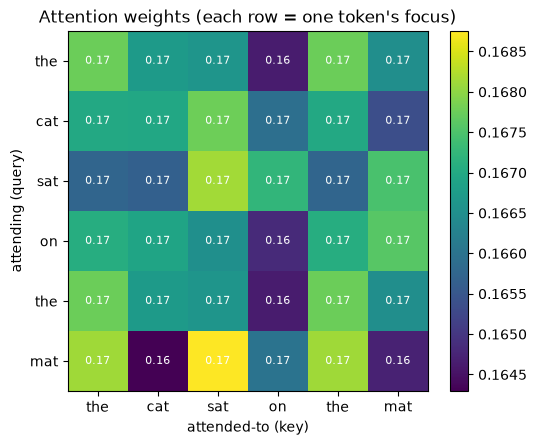

In [5]:
def softmax(M):
    M = M - M.max(axis=1, keepdims=True)   # numerical stability
    e = np.exp(M)
    return e / e.sum(axis=1, keepdims=True)

attn = softmax(scores)
print('each row sums to 1?', np.allclose(attn.sum(axis=1), 1))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(attn, cmap='viridis')
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_xlabel('attended-to (key)'); ax.set_ylabel('attending (query)')
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f'{attn[i,j]:.2f}', ha='center', va='center',
                color='white' if attn[i,j] < 0.25 else 'black', fontsize=8)
plt.colorbar(im); ax.set_title('Attention weights (each row = one token\'s focus)')
plt.tight_layout(); plt.show()

## The output: a weighted sum of value vectors

Finally each token's new representation is the attention-weighted sum of the
value vectors — a matrix multiply again:

$$\text{output} = \text{attn} \cdot V$$

Every token's output is a blend of the whole sentence's information, weighted by
relevance. That is the entire mechanism — three projections, one inner-product
matrix, a softmax, and a weighted sum.

In [6]:
output = attn @ V
print('output:', output.shape, '(one refined vector per token)')

def self_attention(X, WQ, WK, WV, mask=None):
    Q, K, V = X @ WQ, X @ WK, X @ WV
    scores = (Q @ K.T) / np.sqrt(WQ.shape[1])
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    return softmax(scores) @ V

print('one-call self-attention matches step-by-step?',
      np.allclose(self_attention(X, WQ, WK, WV), output))

output: (6, 32) (one refined vector per token)
one-call self-attention matches step-by-step? True


## A language model can't see the future: the causal mask

To *generate* text left-to-right, a token may only attend to tokens **before**
it. That is enforced by zeroing the upper triangle of the score matrix before
the softmax — a lower-triangular mask. Pure linear algebra again.

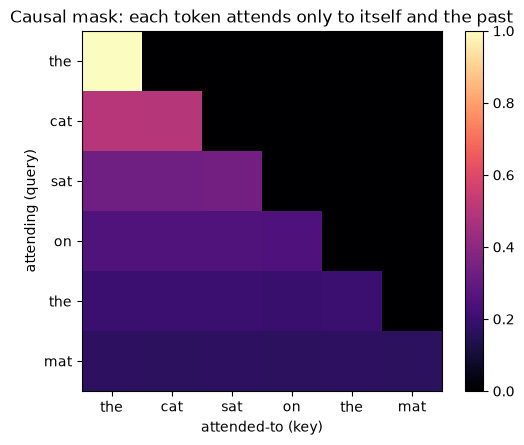

upper triangle is zero (no peeking ahead):
[[1.   0.   0.   0.   0.   0.  ]
 [0.5  0.5  0.   0.   0.   0.  ]
 [0.33 0.33 0.34 0.   0.   0.  ]
 [0.25 0.25 0.25 0.25 0.   0.  ]
 [0.2  0.2  0.2  0.2  0.2  0.  ]
 [0.17 0.16 0.17 0.17 0.17 0.16]]


In [7]:
causal = np.tril(np.ones((len(tokens), len(tokens)), dtype=bool))   # lower triangular
masked_scores = np.where(causal, (Q @ K.T) / np.sqrt(dk), -np.inf)
masked_attn = softmax(masked_scores)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(masked_attn, cmap='magma')
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_xlabel('attended-to (key)'); ax.set_ylabel('attending (query)')
ax.set_title('Causal mask: each token attends only to itself and the past')
plt.colorbar(im); plt.tight_layout(); plt.show()
print('upper triangle is zero (no peeking ahead):')
print(masked_attn.round(2))

## Recap — the transformer is this, repeated

A real model like Claude stacks this operation dozens of times, runs several
heads in parallel (each attending in a different **subspace** — the tensor-
product structure of Lectures 6 and 9), and interleaves simple nonlinearities.
But the load-bearing step is the one you just built:

| Step | The linear algebra | Course lecture |
|------|--------------------|----------------|
| $QK^\top$ | inner products of all token pairs | Lec. 4, 8 |
| softmax | normalize each row to weights | — |
| $\text{attn}\cdot V$ | weighted sum of value vectors | Lec. 3, 8 |
| multi-head | parallel subspaces | Lec. 6, 9 |
| causal mask | lower-triangular matrix | Lec. 8 |

This is the concrete, runnable proof of the methodology's core claim: **a
language model is linear algebra** — the same vectors, inner products, and
matrices this course teaches, arranged into attention.

## Exercises

1. Make the projections meaningful: set `WK = WQ` and normalize, so tokens
   attend to *similar* tokens. Do the two `the` tokens attend to each other?
2. Implement **multi-head** attention: split `dk` into 4 heads, run attention in
   each, and concatenate the outputs.
3. Scale the scores by different factors (no $\sqrt{d_k}$, or $/d_k$). How does
   the sharpness of the attention weights change?
4. Feed a longer sentence and find which token each token attends to most.
5. Connect to Lecture 16: the softmax of $QK^\top$ is not symmetric, but
   $QK^\top$ has an SVD — what do its top singular vectors represent?

